## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

---

### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*
2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr, spearmanr
import scipy.stats as stats

In [14]:

# Show all columns in output
pd.set_option('display.max_columns', None)

# Load the dataset — update path as needed
data = pd.read_csv('amz_uk_price_prediction_dataset.csv')

In [ ]:
#Solution to Part 1: Crosstab Analysis 
df = data.copy()
df = df.dropna(subset=['isBestSeller', 'category'])
df['isBestSeller'] = df['isBestSeller'].astype(bool)

# Row-wise normalization: what % of each CATEGORY is a best-seller?
# normalize='index' means each ROW sums to 1 (per-category proportions)
row_crosstab = pd.crosstab(df['category'], df['isBestSeller'], normalize='index') * 100

# Rename columns for clarity
row_crosstab.columns = ['Not BestSeller (%)', 'IsBestSeller (%)']

# Sort by best-seller % descending
row_crosstab_sorted = row_crosstab.sort_values('IsBestSeller (%)', ascending=False)

print("=== Row-normalized Crosstab (% within each category) ===")
print(row_crosstab_sorted)

# Column-wise normalization: within all best-sellers, how many come from each category?
# normalize='columns' means each COLUMN sums to 1
col_crosstab = pd.crosstab(df['category'], df['isBestSeller'], normalize='columns') * 100
col_crosstab.columns = ['Share of Non-BestSellers (%)', 'Share of BestSellers (%)']

print("\n=== Column-normalized Crosstab (% within True/False group) ===")
print(col_crosstab.sort_values('Share of BestSellers (%)', ascending=False))


=== Row-normalized Crosstab (% within each category) ===
                                  Not BestSeller (%)  IsBestSeller (%)
category                                                              
Grocery                                    94.186533          5.813467
Smart Home Security & Lighting             94.230769          5.769231
Health & Personal Care                     94.231372          5.768628
Mobile Phone Accessories                   95.752896          4.247104
Power & Hand Tools                         96.466105          3.533895
...                                              ...               ...
CD, Disc & Tape Players                   100.000000          0.000000
General Music-Making Accessories          100.000000          0.000000
Snowboard Boots                           100.000000          0.000000
Boxes & Organisers                        100.000000          0.000000
eBook Readers & Accessories               100.000000          0.000000

[296 rows x 2 colum

In [ ]:

# Chi-Square test
contingency_table = pd.crosstab(df['isBestSeller'], df['category'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Cramér's V — measures STRENGTH of association (0 = none, 1 = perfect)
# Formula: V = sqrt(chi2 / (n * (min(r,c) - 1)))
# where n = total observations, r = rows, c = columns
n = contingency_table.values.sum()       # total number of observations
r, c = contingency_table.shape           # number of rows and columns
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("=== Chi-Square + Cramér's V ===")
print(f"Chi2 Statistic    : {chi2:.2f}")
print(f"P-value           : {p_value:.4e}")
print(f"Degrees of Freedom: {dof}")
print(f"Cramér's V        : {cramers_v:.4f}")
print(f"\nInterpretation:")
print(f"  H0 Rejected?    : {'YES' if p_value < 0.05 else 'NO'}")
if cramers_v < 0.1:
    strength = "Negligible"
elif cramers_v < 0.2:
    strength = "Weak"
elif cramers_v < 0.4:
    strength = "Moderate"
else:
    strength = "Strong"
print(f"  Association     : {strength} (V = {cramers_v:.4f})")

=== Chi-Square + Cramér's V ===
Chi2 Statistic    : 36540.20
P-value           : 0.0000e+00
Degrees of Freedom: 295
Cramér's V        : 0.1223

Interpretation:
  H0 Rejected?    : YES
  Association     : Weak (V = 0.1223)


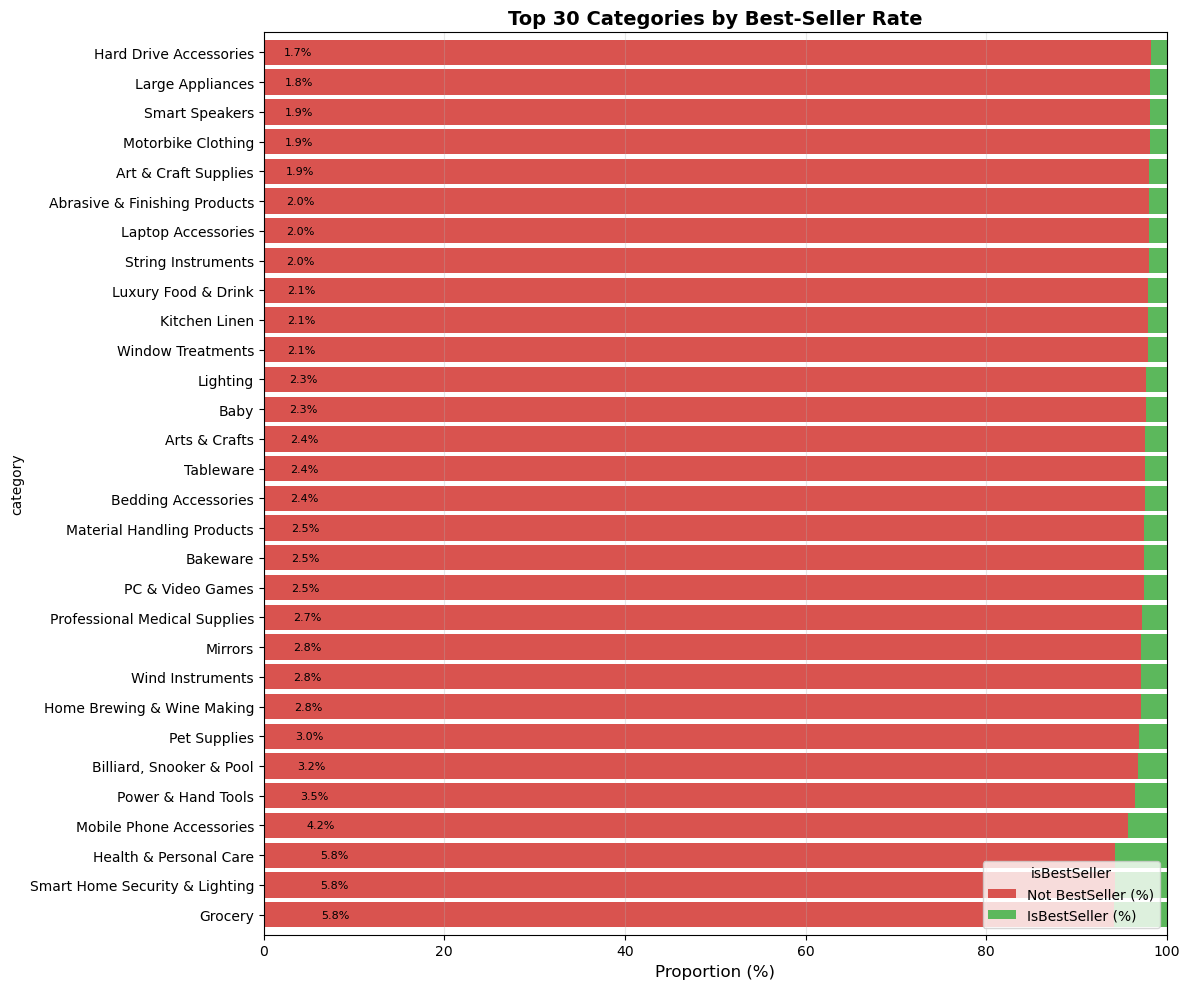

In [7]:
# Only show top 30 categories by best-seller rate for readability
crosstab_plot = pd.crosstab(df['category'], df['isBestSeller'], normalize='index') * 100
crosstab_plot.columns = ['Not BestSeller (%)', 'IsBestSeller (%)']
top30 = crosstab_plot.sort_values('IsBestSeller (%)', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 10))

# Use a meaningful color palette: green for best-sellers, red for non
top30.plot(
    kind='barh', stacked=True, ax=ax,
    color=['#d9534f', '#5cb85c'],  # red = not best-seller, green = best-seller
    width=0.85
)

ax.set_xlabel('Proportion (%)', fontsize=12)
ax.set_title('Top 30 Categories by Best-Seller Rate', fontsize=14, fontweight='bold')
ax.legend(title='isBestSeller', loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 100)

# Add % labels on the best-seller bars
for i, (idx, row) in enumerate(top30.iterrows()):
    ax.text(row['IsBestSeller (%)'] + 0.5, i, f"{row['IsBestSeller (%)']:.1f}%",
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.


In [8]:
# Remove Price Outliers (IQR Method)

df = df.dropna(subset=['price', 'category'])

# IQR calculation in one clean pipeline
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter using boolean mask — more readable than chaining
mask = df['price'].between(lower_bound, upper_bound)
df_clean = df[mask].copy()

# Summary report
removed = len(df) - len(df_clean)
pct_removed = (removed / len(df)) * 100

print(f"Bounds        : [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Rows kept     : {len(df_clean):,}  ({100 - pct_removed:.1f}%)")
print(f"Rows removed  : {removed:,}  ({pct_removed:.1f}%)")
print(f"\nPrice stats after cleaning:")
print(df_clean['price'].describe().round(2))

Bounds        : [-44.01, 99.99]
Rows kept     : 2,115,963  (86.6%)
Rows removed  : 327,688  (13.4%)

Price stats after cleaning:
count    2115963.00
mean          23.41
std           20.51
min            0.00
25%            9.13
50%           15.99
75%           29.99
max           99.99
Name: price, dtype: float64


C:\Users\KaoticCharma\AppData\Local\Temp\ipykernel_14832\458786808.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\KaoticCharma\AppData\Local\Temp\ipykernel_14832\458786808.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


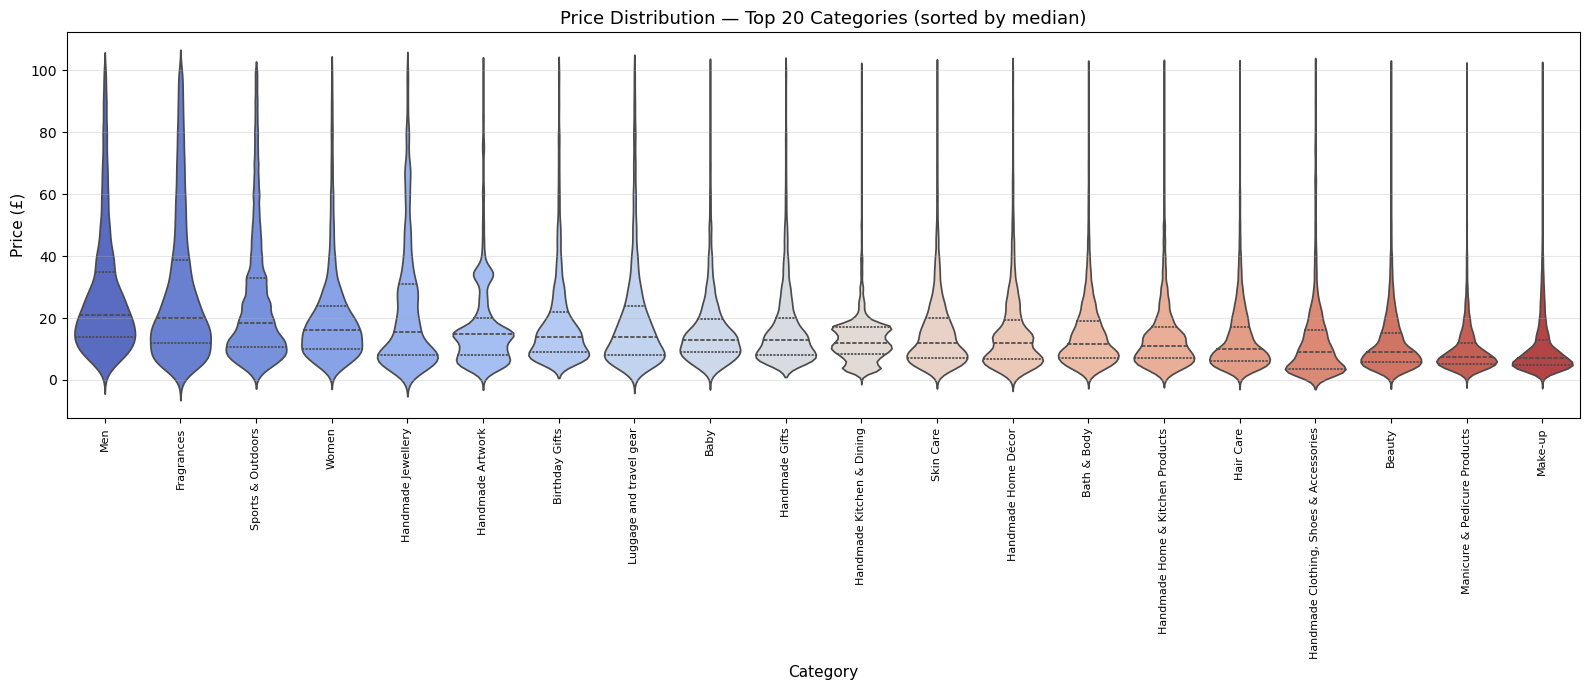


Highest median price (all categories): Desktop PCs — £74.00


In [ ]:
# Violin Plot: Price Distribution by Category (Top 20)
# Top 20 categories by count
top20_cats = df_clean['category'].value_counts().head(20).index
df_filter = df_clean[df_clean['category'].isin(top20_cats)].copy()

# Sort categories by their median price (descending) for better visual ordering
cat_order = (df_filter.groupby('category')['price']
             .median()
             .sort_values(ascending=False)
             .index)

fig, ax = plt.subplots(figsize=(16, 7))

sns.violinplot(
    data=df_filter,
    x='category', y='price',
    order=cat_order,          # sorted by median price
    palette='coolwarm',
    inner='quartile',         # shows Q1, median, Q3 lines inside the violin
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_title('Price Distribution — Top 20 Categories (sorted by median)', fontsize=13)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Price (£)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Highest median price — no filter
top_median_cat = df_clean.groupby('category')['price'].median().idxmax()
top_median_val = df_clean.groupby('category')['price'].median().max()
print(f"\nHighest median price (all categories): {top_median_cat} — £{top_median_val:.2f}")

C:\Users\KaoticCharma\AppData\Local\Temp\ipykernel_14832\146422459.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stats.index, rotation=45, ha='right', fontsize=9)


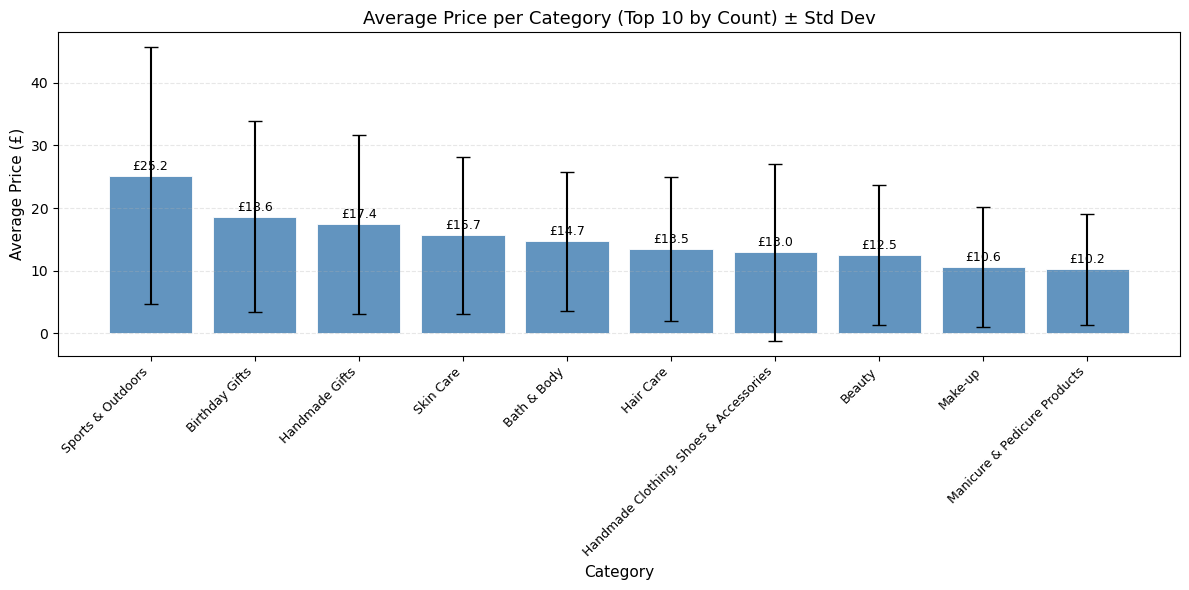


Highest avg price (all categories): Motherboards — £68.77


In [10]:
# Bar Chart — Average Price by Category (Top 10)
top10_cats = df_clean['category'].value_counts().head(10).index
df_top10 = df_clean[df_clean['category'].isin(top10_cats)]

# Compute mean + std for error bars
stats = df_top10.groupby('category')['price'].agg(['mean', 'std']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars with error bars (std deviation shows spread)
bars = ax.bar(stats.index, stats['mean'],
              yerr=stats['std'],            # error bars = 1 standard deviation
              capsize=5,
              color='steelblue', alpha=0.85,
              edgecolor='white', linewidth=0.7)

# Add value labels on top of each bar
for bar, val in zip(bars, stats['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"£{val:.1f}", ha='center', va='bottom', fontsize=9)

ax.set_title('Average Price per Category (Top 10 by Count) ± Std Dev', fontsize=13)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Average Price (£)', fontsize=11)
ax.set_xticklabels(stats.index, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# All categories — highest average price
all_avg = df_clean.groupby('category')['price'].mean()
print(f"\nHighest avg price (all categories): {all_avg.idxmax()} — £{all_avg.max():.2f}")

C:\Users\KaoticCharma\AppData\Local\Temp\ipykernel_14832\1522362076.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='category', y='stars', palette='Set2')


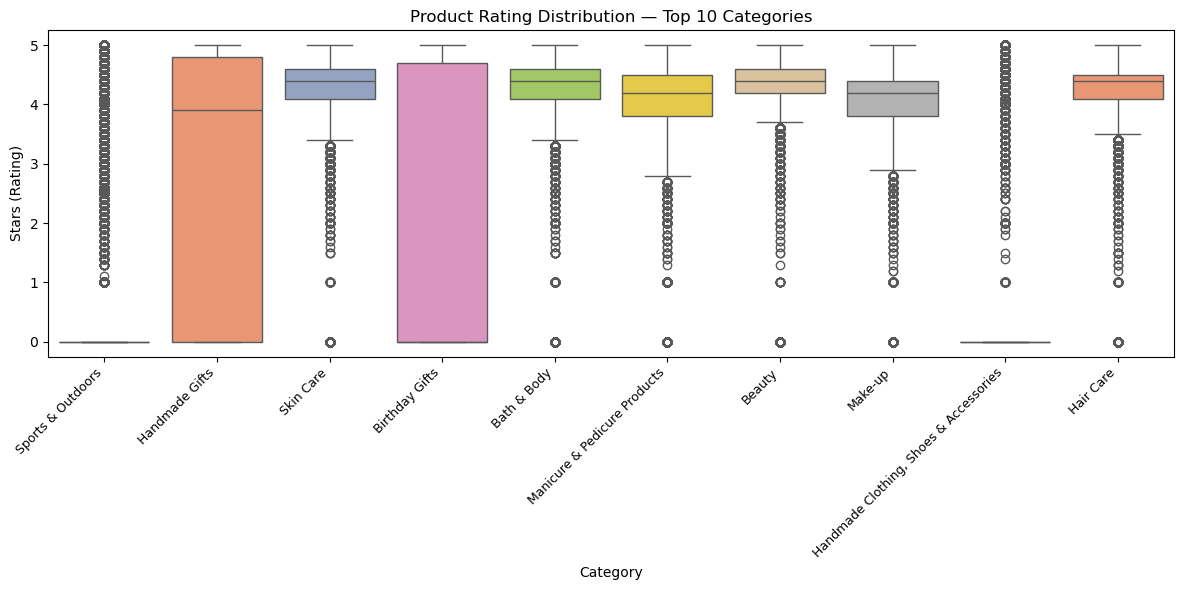


Highest median rating: Computer Memory
Median Stars: 4.70


In [ ]:
#Box Plot: Stars Distribution by Category (Top 10)
# Step 1: Top 10 categories by count
top10_cats = df_clean['category'].value_counts().head(10).index
df_top10 = df_clean[df_clean['category'].isin(top10_cats)]

# Step 2: Box plot of stars per category
plt.figure(figsize=(12, 6))

# Box plot shows: min, Q1, median, Q3, max and outliers as dots
sns.boxplot(data=df_top10, x='category', y='stars', palette='Set2')

plt.title('Product Rating Distribution — Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Stars (Rating)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# Step 3: Highest median rating (ALL categories — no filter)
median_stars = df_clean.groupby('category')['stars'].median()
print(f"\nHighest median rating: {median_stars.idxmax()}")
print(f"Median Stars: {median_stars.max():.2f}")

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?
	
2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?


In [15]:
# 1 Correlation Coefficient : Pearson's r between price and stars

df_corr = df_clean.dropna(subset=['price', 'stars'])

# Pearson — assumes both variables are normally distributed and linear relationship
pearson_r, pearson_p = pearsonr(df_corr['price'], df_corr['stars'])

# Spearman — rank-based, does NOT assume normality or linearity
# Better choice when data is skewed (which price data often is)
spearman_r, spearman_p = spearmanr(df_corr['price'], df_corr['stars'])

print("=== Pearson Correlation (linear) ===")
print(f"  r       : {pearson_r:.4f}")
print(f"  p-value : {pearson_p:.4e}")
print(f"  Result  : {'Significant' if pearson_p < 0.05 else 'Not significant'}")

print("\n=== Spearman Correlation (rank-based) ===")
print(f"  rho     : {spearman_r:.4f}")
print(f"  p-value : {spearman_p:.4e}")
print(f"  Result  : {'Significant' if spearman_p < 0.05 else 'Not significant'}")

# Interpret strength
def interpret_strength(r):
    """Interpret the absolute magnitude of a correlation coefficient."""
    r = abs(r)
    if r < 0.1:   return "Negligible"
    elif r < 0.3: return "Weak"
    elif r < 0.5: return "Moderate"
    elif r < 0.7: return "Strong"
    else:         return "Very Strong"

print(f"\nPearson strength  : {interpret_strength(pearson_r)}")
print(f"Spearman strength : {interpret_strength(spearman_r)}")

=== Pearson Correlation (linear) ===
  r       : -0.0777
  p-value : 0.0000e+00
  Result  : Significant

=== Spearman Correlation (rank-based) ===
  rho     : -0.0668
  p-value : 0.0000e+00
  Result  : Significant

Pearson strength  : Negligible
Spearman strength : Negligible


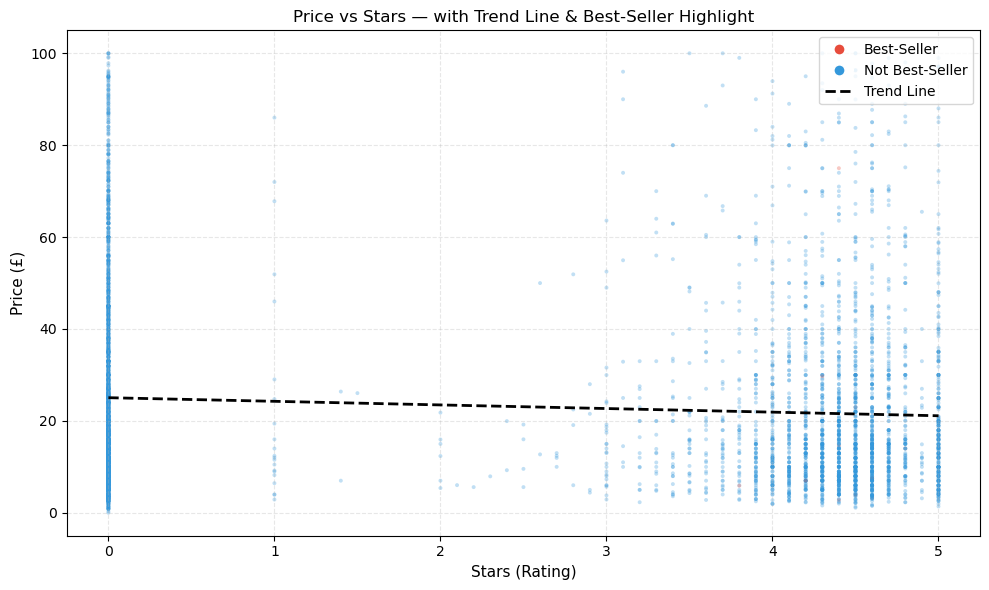

In [ ]:
# Visualize the relationship with a scatter plot + trend line
df_sample = df_corr.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

# Color-code by isBestSeller to reveal another dimension
colors = df_sample['isBestSeller'].map({True: '#e74c3c', False: '#3498db'})

scatter = ax.scatter(
    df_sample['stars'], df_sample['price'],
    c=colors, alpha=0.3, s=8, linewidths=0
)

# Add a linear regression trend line using numpy polyfit
# polyfit(x, y, deg=1) fits a degree-1 (straight line) polynomial
z = np.polyfit(df_sample['stars'], df_sample['price'], 1)
p = np.poly1d(z)                              # build the line function
x_line = np.linspace(df_sample['stars'].min(), df_sample['stars'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linewidth=2,
        linestyle='--', label=f'Trend (slope={z[0]:.2f})')

ax.set_xlabel('Stars (Rating)', fontsize=11)
ax.set_ylabel('Price (£)', fontsize=11)
ax.set_title('Price vs Stars — with Trend Line & Best-Seller Highlight', fontsize=12)

# Manual legend for colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
           markersize=8, label='Best-Seller'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
           markersize=8, label='Not Best-Seller'),
    Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Trend Line')
]
ax.legend(handles=legend_elements, loc='upper right')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

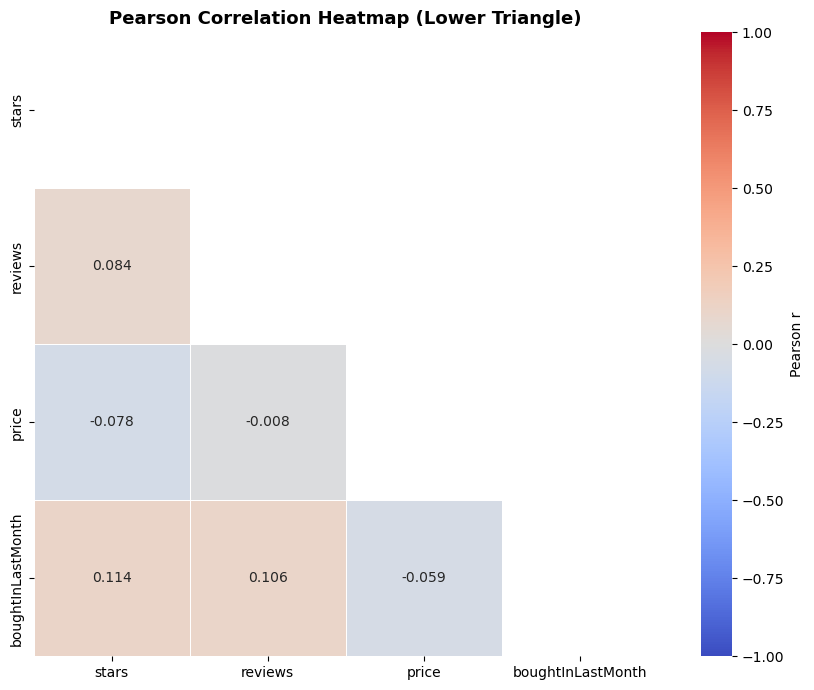

In [17]:
# Also do a correlation heatmap for all numeric columns to see if there are any other interesting relationships

# Select numeric columns and compute Pearson correlation matrix
numeric_df = df_clean.select_dtypes(include='number').drop(columns=['uid'], errors='ignore')
corr_matrix = numeric_df.corr(method='pearson')

# Generate a mask to hide the upper triangle (avoid duplicate info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    mask=mask,               # hides upper triangle — each pair shown once
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,                # white = 0 correlation
    vmin=-1, vmax=1,         # fix color scale to full [-1, 1] range
    square=True,             # make each cell square-shaped
    linewidths=0.5,
    cbar_kws={'label': 'Pearson r'},
    ax=ax
)

ax.set_title('Pearson Correlation Heatmap (Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

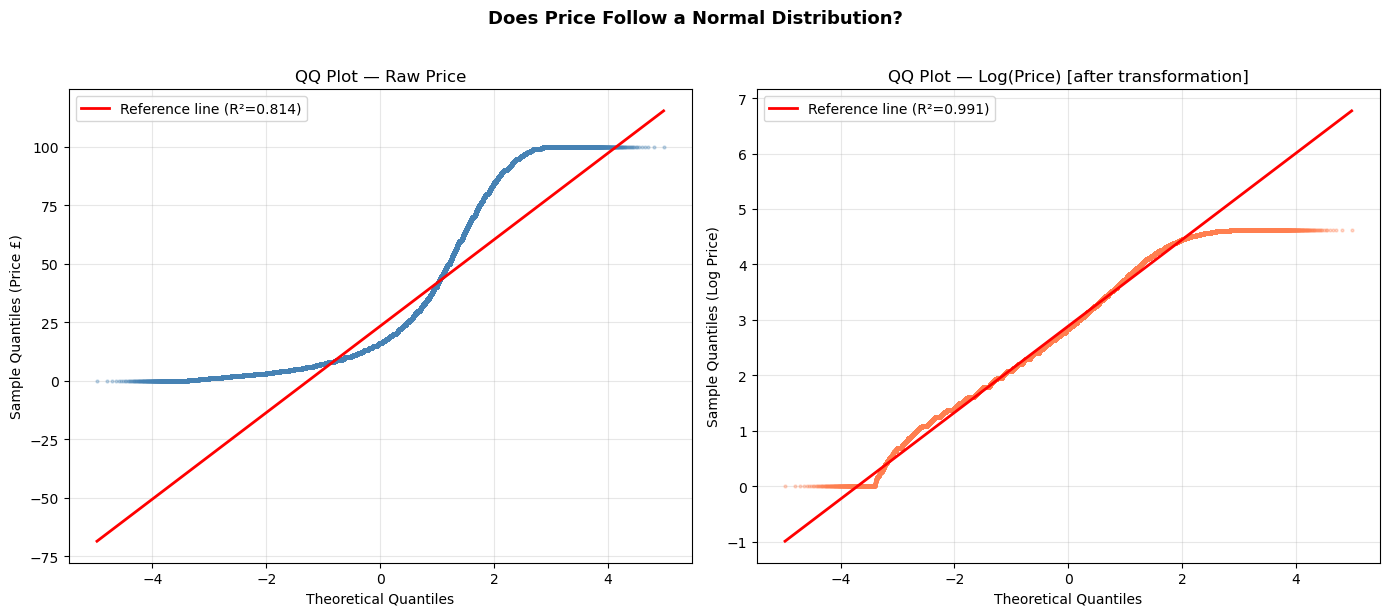

In [20]:
# 2 Normality Check: QQ Plots for Price (raw vs log-transformed)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT: QQ plot of raw prices ---
(quantiles, values), (slope, intercept, r) = stats.probplot(
    df_clean['price'], dist='norm'
)
axes[0].plot(quantiles, values, 'o', markersize=2, alpha=0.3, color='steelblue')
axes[0].plot(quantiles, slope * np.array(quantiles) + intercept,
             'r-', linewidth=2, label=f'Reference line (R²={r**2:.3f})')
axes[0].set_title('QQ Plot — Raw Price', fontsize=12)
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Sample Quantiles (Price £)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- RIGHT: QQ plot of LOG-transformed prices ---
# Log transformation often normalizes right-skewed data
log_price = np.log1p(df_clean['price'])   # log1p = log(1+x) handles zeros safely
(quantiles2, values2), (slope2, intercept2, r2) = stats.probplot(
    log_price, dist='norm'
)
axes[1].plot(quantiles2, values2, 'o', markersize=2, alpha=0.3, color='coral')
axes[1].plot(quantiles2, slope2 * np.array(quantiles2) + intercept2,
             'r-', linewidth=2, label=f'Reference line (R²={r2**2:.3f})')
axes[1].set_title('QQ Plot — Log(Price) [after transformation]', fontsize=12)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles (Log Price)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Does Price Follow a Normal Distribution?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()